正在读取全市场数据，请稍候...
正在计算基本面质量指标 (ROE与净资产)...
开始执行【高ROE长线白马】半年度轮动模拟...

✅ 回测完成！正在处理结果...
交易明细已成功导出至: F:\self_quant\data\data\高ROE质量白马策略明细.xlsx
💰 初始本金: 50,000.00 元
💰 质量白马最终总资产: 20,555.08 元
📈 策略总收益率: -58.89%


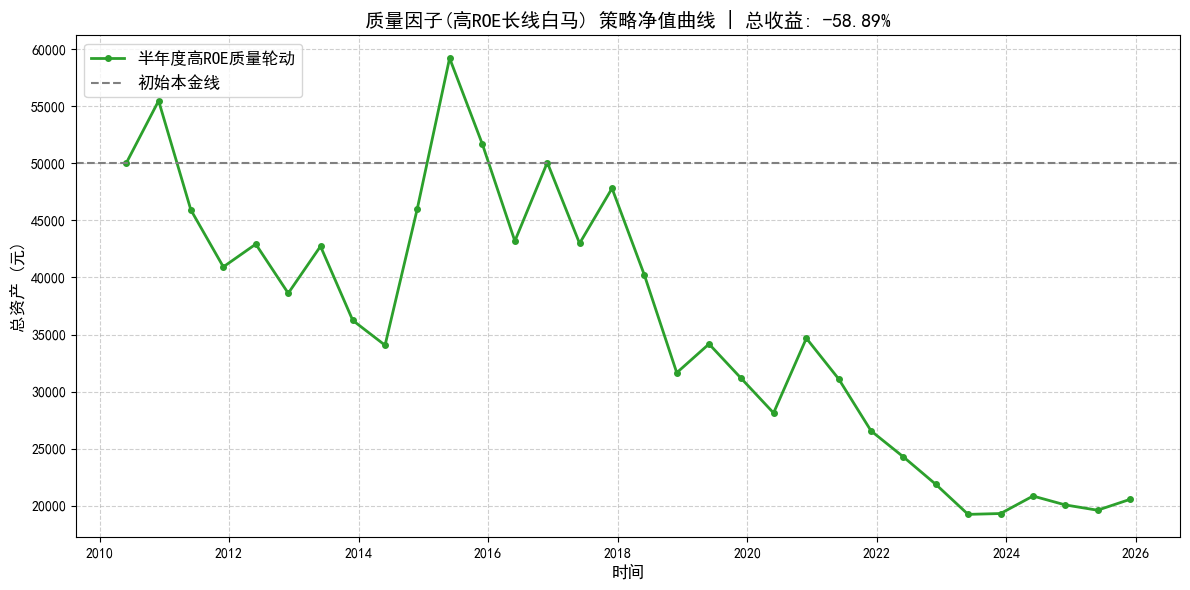

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# 设置绘图支持中文
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 第一步：配置参数与读取数据
# ==========================================
FILE_PATH =r"F:\self_quant\data\data\all_stocks_merged_fixed.parquet"
OUTPUT_EXCEL = r"F:\self_quant\data\data\高ROE质量白马策略明细.xlsx"

INITIAL_CASH = 50000.0
TARGET_STOCK_NUM = 10
ROE_THRESHOLD = 0.15    # ROE 门槛：15%

print("正在读取全市场数据，请稍候...")
df = pd.read_parquet(FILE_PATH)
df['date'] = pd.to_datetime(df['date'])

main_board_mask = df['code'].str.contains(r'^sh\.60|^sz\.00', regex=True)
df = df[main_board_mask].copy()

# ==========================================
# 第二步：计算核心财务指标 (ROE)
# ==========================================
print("正在计算基本面质量指标 (ROE与净资产)...")
# 计算净资产 = 资产总计 - 负债合计
df['净资产'] = df['资产总计'] - df['负债合计']

# 计算 ROE (剔除资不抵债的公司，避免除以负数导致ROE虚高)
df['ROE'] = np.where(df['净资产'] > 0, df['净利润'] / df['净资产'], -1)

# ==========================================
# 第三步：生成【半年度】调仓日
# ==========================================
# 提取每个月的最后一个交易日
df['year_month'] = df['date'].dt.to_period('M')
all_month_ends = df.groupby('year_month')['date'].max()

# 过滤出 5月末 (年报/一季报披露完毕) 和 11月末 (三季报披露完毕) 作为调仓日
trade_dates = all_month_ends[all_month_ends.dt.month.isin([5, 11])].sort_values().tolist()

# ==========================================
# 第四步：定义交易费率与账户类
# ==========================================
def calculate_fees(trade_type, price, volume):
    amount = price * volume
    commission = max(5.0, amount * 0.00025)
    transfer_fee = amount * 0.00001
    stamp_duty = amount * 0.0005 if trade_type == 'sell' else 0.0
    return commission + transfer_fee + stamp_duty, amount

class Account:
    def __init__(self, initial_cash):
        self.cash = initial_cash
        self.positions = {}
        self.trade_logs = []
        self.history_assets = []

    def get_total_asset(self, current_prices_dict):
        stock_value = 0
        for code, pos in self.positions.items():
            stock_value += pos['volume'] * current_prices_dict.get(code, pos['price'])
        return self.cash + stock_value

account = Account(INITIAL_CASH)

# ==========================================
# 第五步：执行半年度质量轮动引擎
# ==========================================
print("开始执行【高ROE长线白马】半年度轮动模拟...")

# 提取按日期索引的数据字典，加快切片速度
grouped_by_date = dict(tuple(df.groupby('date')))

for date in trade_dates:
    if date not in grouped_by_date:
        continue

    daily_data = grouped_by_date[date].set_index('code')
    current_prices = daily_data['close'].to_dict()
    status_dict = daily_data['tradestatus'].to_dict()
    st_dict = daily_data['isST'].to_dict()
    pct_chg_dict = daily_data['pctChg'].to_dict()

    current_asset = account.get_total_asset(current_prices)
    account.history_assets.append({'date': date, 'total_asset': current_asset})

    # ---------------- 1. 选股逻辑 (高质量白马) ----------------
    # 基础过滤：正常交易、非ST
    valid_pool = daily_data[
        (daily_data['tradestatus'] == 1) &
        (daily_data['isST'] == 0) &
        (daily_data['pcfNcfTTM'] > 0) &   # 经营现金流充沛
        (daily_data['peTTM'] > 0)         # 剔除亏损股
    ].copy()

    target_codes = []
    if len(valid_pool) >= 50:
        # 护城河1：只在流通市值前 50% 的中大盘股中挑选（过滤掉微盘股）
        median_mv = valid_pool['流通市值'].median()
        large_cap_pool = valid_pool[valid_pool['流通市值'] >= median_mv].copy()

        # 护城河2：ROE > 15%
        quality_pool = large_cap_pool[large_cap_pool['ROE'] >= ROE_THRESHOLD].copy()

        if len(quality_pool) >= TARGET_STOCK_NUM:
            # 在满足高ROE和现金流的大盘股中，按照估值 (PE) 从低到高排序，买入最便宜的 10 只
            target_codes = quality_pool.sort_values(by='peTTM', ascending=True).head(TARGET_STOCK_NUM).index.tolist()
        else:
            # 如果极端熊市下好公司不够，按ROE降序选最好的几只
            target_codes = large_cap_pool.sort_values(by='ROE', ascending=False).head(TARGET_STOCK_NUM).index.tolist()

    # ---------------- 2. 卖出逻辑 (剔除基本面恶化的股票) ----------------
    current_holdings = list(account.positions.keys())
    for code in current_holdings:
        if code not in target_codes:
            is_trading = status_dict.get(code, 0) == 1
            pct_chg = pct_chg_dict.get(code, 0)

            if is_trading and pct_chg > -9.8:
                sell_price = current_prices[code]
                sell_vol = account.positions[code]['volume']
                fee, amount = calculate_fees('sell', sell_price, sell_vol)

                account.cash += (amount - fee)
                del account.positions[code]

                account.trade_logs.append({
                    '日期': date, '股票代码': code, '买卖方向': '卖出(定期调仓)',
                    '成交价': sell_price, '成交股数': sell_vol,
                    '成交金额': round(amount, 2), '可用现金': round(account.cash, 2),
                    '总资产': round(account.get_total_asset(current_prices), 2),
                    '备注': '基本面不再处于前列'
                })
            elif pct_chg <= -9.8:
                account.trade_logs.append({
                    '日期': date, '股票代码': code, '买卖方向': '卖出失败(跌停)',
                    '成交价': 0, '成交股数': 0, '成交金额': 0, '可用现金': round(account.cash, 2),
                    '总资产': round(account.get_total_asset(current_prices), 2),
                    '备注': f'跌幅 {pct_chg:.2f}% 封死跌停'
                })

    # ---------------- 3. 买入逻辑 (买入优质白马) ----------------
    stocks_to_buy = [code for code in target_codes if code not in account.positions]

    if len(stocks_to_buy) > 0:
        target_cash_per_stock = account.cash / len(stocks_to_buy)

        for code in stocks_to_buy:
            is_trading = status_dict.get(code, 0) == 1
            pct_chg = pct_chg_dict.get(code, 0)
            is_st = st_dict.get(code, 0) == 1

            if is_trading and not is_st and pct_chg < 9.8:
                buy_price = current_prices[code]
                affordable_shares = int((target_cash_per_stock * 0.997) / buy_price)
                buy_vol = (affordable_shares // 100) * 100

                if buy_vol >= 100:
                    fee, amount = calculate_fees('buy', buy_price, buy_vol)

                    if account.cash >= (amount + fee):
                        account.cash -= (amount + fee)
                        account.positions[code] = {'volume': buy_vol, 'price': buy_price}

                        roe_val = daily_data.loc[code, 'ROE']
                        account.trade_logs.append({
                            '日期': date, '股票代码': code, '买卖方向': '买入(高质量)',
                            '成交价': buy_price, '成交股数': buy_vol,
                            '成交金额': round(amount, 2), '可用现金': round(account.cash, 2),
                            '总资产': round(account.get_total_asset(current_prices), 2),
                            '备注': f'ROE: {roe_val:.1%}'
                        })

# ==========================================
# 第六步：输出结果与可视化
# ==========================================
print("\n✅ 回测完成！正在处理结果...")
df_trades = pd.DataFrame(account.trade_logs)
df_trades.to_excel(OUTPUT_EXCEL, index=False)
print(f"交易明细已成功导出至: {OUTPUT_EXCEL}")

# 为了画图连贯，我们要把调仓日之间的净资产也补齐
# 这里简单处理，只画调仓日的连线
df_assets = pd.DataFrame(account.history_assets)
df_assets.set_index('date', inplace=True)
final_asset = df_assets['total_asset'].iloc[-1]
total_return = (final_asset - INITIAL_CASH) / INITIAL_CASH * 100

print(f"💰 初始本金: {INITIAL_CASH:,.2f} 元")
print(f"💰 质量白马最终总资产: {final_asset:,.2f} 元")
print(f"📈 策略总收益率: {total_return:.2f}%")

plt.figure(figsize=(12, 6))
plt.plot(df_assets.index, df_assets['total_asset'], color='#2ca02c', linewidth=2, marker='o', markersize=4, label='半年度高ROE质量轮动')
plt.title(f'质量因子(高ROE长线白马) 策略净值曲线 | 总收益: {total_return:.2f}%', fontsize=14)
plt.xlabel('时间', fontsize=12)
plt.ylabel('总资产 (元)', fontsize=12)
plt.axhline(y=INITIAL_CASH, color='gray', linestyle='--', label='初始本金线')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()